In [1]:
import os
import sys
import torch
import json
import plotly.express as px
print("importing transformerlens utils")
from transformer_lens import utils
print("finished importing transformerlens utils")
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

cwd = os.getcwd()
cwd = cwd.split("notebooks")[0]
print(cwd)
sys.path.append(cwd + "/scripts")
from error_eval import *
from plots import *

importing transformerlens utils
finished importing transformerlens utils
/n/data2/hms/dbmi/sunyaev/lab/dlee/ai_safety/sae_pathology/


# Get model names

In [2]:
from e2e_sae.scripts.analysis.utils import create_run_df, get_df_gpt2
df = get_df_gpt2()

Processing runs: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 299/299 [00:12<00:00, 24.64it/s]


In [3]:
performance_df = df.copy()

#get models that were used in the performance plot of the paper
performance_df = df.loc[(df["ratio"] == 60) & (df["seed"] == 0) & (df["n_samples"] == 400_000)]

# Ignore specialised runs
performance_df = performance_df.loc[
    ~performance_df["name"].str.contains("seed-comparison")
    & ~performance_df["name"].str.contains("lr-comparison")
    & ~performance_df["name"].str.contains("lower-downstream")
    & -performance_df["name"].str.contains("e2e-local")
    & ~performance_df["name"].str.contains("recon-all")
    & ~performance_df["name"].str.contains("misc_")]


In [4]:
columns_list = ["id", "sae_pos", "run_type", "layer", "L0", "CELossIncrease", "alive_dict_elements"]
df_local = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "local")].sort_values("L0")
df_e2e = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "e2e")].sort_values("L0")
df_downstream = performance_df[(performance_df["layer"] == 6) & (performance_df["run_type"] == "downstream")].sort_values("L0")

In [6]:
df_local[["id"]]

,id
296,ahxwn90o
297,43zmudf4
285,unji5etq
295,jup3glm9
287,h9hrelni
298,1jy3m5j0
212,4nlqrc2y
213,2wvu1zs5
286,uiwt81f1


In [8]:
def plot_modelwise_kl_average(result_dfs, models, kl_cols, kl_col_labels, model_name_list):
    mean_df = pd.DataFrame({
        l: result_dfs[l].mean(axis=0) for l in range(len(models))
    }).T

    fig, ax = plt.subplots(figsize=(10, 5))

    mean_df["Model Name"] = model_name_list
    mean_df[kl_cols + ["Model Name"]].rename(columns=kl_col_labels).plot(x = "Model Name", kind='bar', ax=ax)

    ax.set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=11)
    ax.set_xlabel('SAE Model', fontsize=12)
    ax.legend(title='Substitution type', fontsize=12, title_fontsize=14)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    format_subplot(ax)
    
    return mean_df, fig, ax

# Replicating Plots

In [14]:
df_local_l0 = df_local[(df_local["L0"] > 40)]

In [15]:
pos = 'all'
# layers = list(range(12))
layers = [6]
sae_name = 'gpt2_resid_pre'

model_list = [f"e2e_{x}" for x in df_local_l0["id"]]
model_list.append("bloom")
# model_names_list = ["e2e_7nkdr21r", "$SAE_local$", "Joseph Bloom's SAE"]

result_dfs = {}
for i in range(len(model_list)):
    data_path = os.path.join(
        cwd + '/error_eval_results',
        sae_name,
        f'{model_list[i]}_layer_6_pos_{pos}.csv',
    )
    result_dfs[i] = pd.read_csv(data_path)
    # result_dfs[i]["model_name"] = model_list[i]

In [16]:
model_names_list = [f"Braun et al. \n$SAE_{{local}}$ \nL0 = {x:.2f}" for x in df_local_l0["L0"]]
model_names_list.append("Joseph Bloom \nSAE \nL0 = 50")

In [24]:
result_dfs[0].columns

Index(['token', 'position', 'loss', 'substitution_loss', 'substitution_kl',
       'norm_corrected_substitution_loss', 'norm_corrected_substitution_kl',
       'cos_corrected_substitution_loss', 'cos_corrected_substitution_kl',
       'l2_error_preserving_substitution_loss',
       'l2_error_preserving_substitution_kl',
       'cos_preserving_substitution_w_sae_norm_loss',
       'cos_preserving_substitution_w_sae_norm_kl',
       'cos_preserving_substitution_w_true_norm_loss',
       'cos_preserving_substitution_w_true_norm_kl', 'zero_ablation_loss',
       'zero_ablation_kl', 'mean_ablation_loss', 'mean_ablation_kl', 'sae_l0',
       'sae_l1', 'reconstruction_error', 'norm', 'sae_norm', 'cos'],
      dtype='object')

In [131]:
col_labels = {
    'substitution_kl': 'SAE(x)',
    'norm_corrected_substitution_kl': 'norm corrected SAE(x)',
    'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
    'l2_error_preserving_substitution_kl': '$\epsilon$-random',
    'cos_preserving_substitution_w_sae_norm_kl': '$\\theta$-random w/ SAE norm',
    'cos_preserving_substitution_w_true_norm_kl': '$\\theta$-random w/ true norm',
    'model_name': 'Model Name',
    'norm_ratio': 'L2 Ratio',
}

kl_main_cols = ['substitution_kl', 'l2_error_preserving_substitution_kl', 'cos_corrected_substitution_kl']
kl_all_cols = ['substitution_kl', 'norm_corrected_substitution_kl', 'l2_error_preserving_substitution_kl', 'cos_corrected_substitution_kl',
               'cos_preserving_substitution_w_sae_norm_kl', 'cos_preserving_substitution_w_true_norm_kl']


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_24326/816211425.py:4: SyntaxWarning: invalid escape sequence '\|'
  'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
/tmp/ipykernel_24326/816211425.py:5: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_kl': '$\epsilon$-random',


In [19]:
def plot_modelwise_kl_average(result_dfs, models, kl_cols, kl_col_labels, model_name_list):
    mean_df = pd.DataFrame({
        l: result_dfs[l].mean(axis=0) for l in range(len(models))
    }).T

    fig, ax = plt.subplots(figsize=(10, 5))

    mean_df["Model Name"] = model_name_list
    mean_df[kl_cols + ["Model Name"]].rename(columns=kl_col_labels).plot(x = "Model Name", kind='bar', ax=ax)

    ax.set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=11)
    ax.set_xlabel('SAE Model', fontsize=12)
    ax.legend(title='Substitution type', fontsize=12, title_fontsize=14)

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    
    format_subplot(ax)
    
    return mean_df, fig, ax

Text(0.5, 1.02, 'Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)')

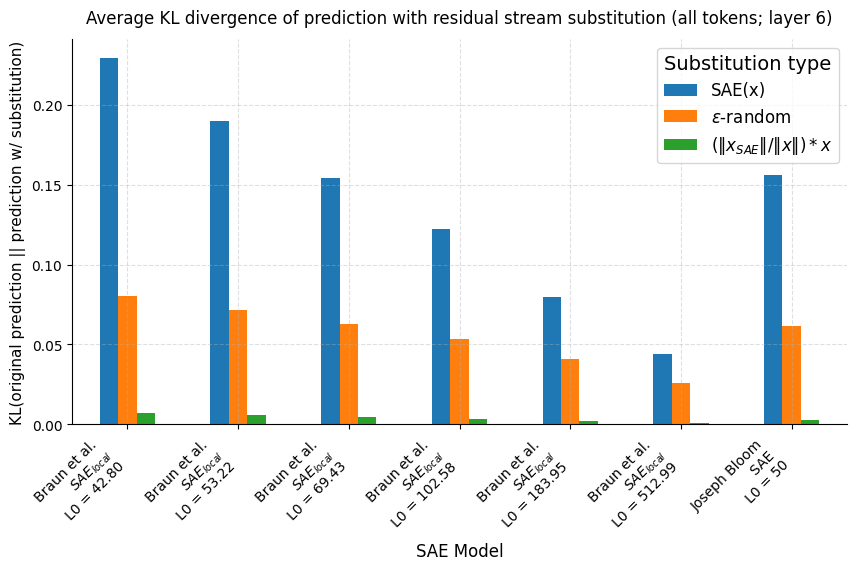

In [20]:
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_main_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

Text(0.5, 1.02, 'Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)')

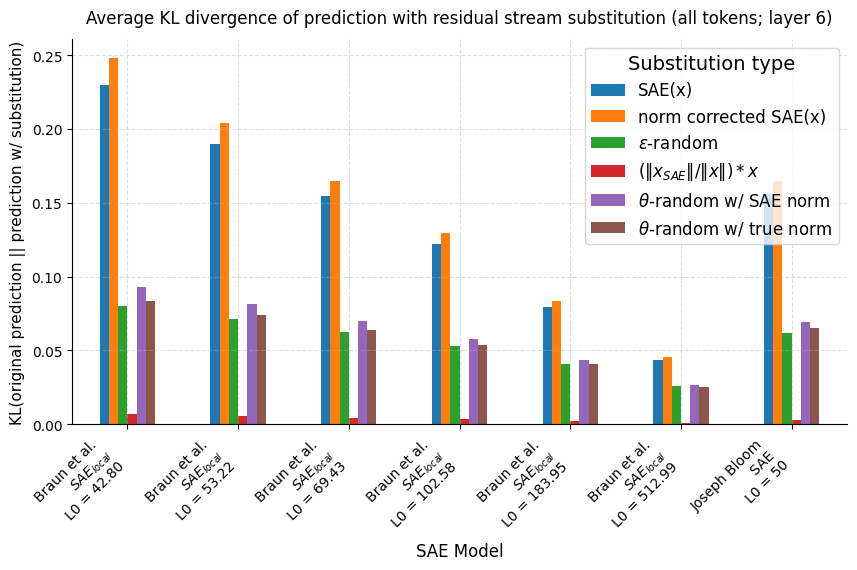

In [26]:
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_all_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

## Compare E2E + ds SAE

In [26]:
df_local["L0"]

296     10.271713
297     17.468240
285     30.945175
295     42.798630
287     53.223964
298     69.426438
212    102.580427
213    183.948012
286    512.987541
Name: L0, dtype: float64

In [36]:
df_interest = df_local[df_local["L0"] > 30]

pos = 'all'
# layers = list(range(12))
layers = [6]
sae_name = 'gpt2_resid_pre'

model_list = [""]
model_list.extend([f"e2e_{x}_" for x in df_interest["id"]])
result_dfs = {}
for i in range(len(model_list)):
    data_path = os.path.join(
        cwd + 'results/error_eval',
        sae_name,
        f'{model_list[i]}layer_6_pos_{pos}.csv',
    )
    result_dfs[i] = pd.read_csv(data_path)

In [37]:
model_names_list = ["Joseph Bloom \nSAE \nL0 = 50"] + [f"Braun et al. \n$SAE_{{local}}$ \nL0 = {x:.1f}" for x in df_interest["L0"]]
# model_names_list.append(["Joseph Bloom \nSAE \nL0 = 50"])

In [12]:
result_dfs

,token,position,loss,substitution_loss,substitution_kl,substitution_blocks.11.hook_resid_post_L2,norm_corrected_substitution_loss,norm_corrected_substitution_kl,norm_corrected_substitution_blocks.11.hook_resid_post_L2,cos_corrected_substitution_loss,...,l2_error_preserving_substitution_cov_random_subtraction_blocks.11.hook_resid_post_L2,l2_error_preserving_substitution_real_activation_subtraction_loss,l2_error_preserving_substitution_real_activation_subtraction_kl,l2_error_preserving_substitution_real_activation_subtraction_blocks.11.hook_resid_post_L2,sae_l0,sae_l1,reconstruction_error,norm,sae_norm,cos
0,50256,0,8.604516,10.660494,1.060914,63.460514,10.684843,1.072742,62.449510,8.568319,...,40.057995,8.982161,0.085825,32.490270,30.0,3011.546000,28.671710,3026.099900,3014.605200,0.999962
1,17402,1,4.787950,5.809247,0.401421,58.221992,5.394247,0.770423,54.303284,5.448551,...,66.303085,4.696027,0.242952,49.798916,8.0,87.941475,32.794926,87.447570,66.415540,0.945491
2,22038,2,3.174024,7.947256,3.193976,129.237440,7.501076,3.025973,126.808304,3.642912,...,71.210300,4.184578,0.315158,82.034870,11.0,90.355100,50.486618,97.552980,74.648280,0.861012
3,4870,3,2.832837,6.054127,1.918791,162.472150,6.021827,1.961387,207.448970,2.303494,...,105.463356,5.058993,0.682380,100.223830,14.0,97.758995,42.932430,92.080620,73.853810,0.888907
4,7806,4,0.000286,2.712109,2.709379,179.443180,3.965794,3.962731,222.682100,0.000632,...,124.011490,0.048177,0.046970,126.230790,10.0,90.116530,43.540590,90.340290,67.242530,0.887873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2031995,3936,122,2.626949,3.502280,0.393355,116.084430,4.127601,0.728052,120.778850,2.757457,...,91.155110,4.175436,0.423451,81.495910,13.0,84.266710,35.132427,89.617874,69.009500,0.934547
2031996,329,123,0.903633,1.801028,0.488871,123.967480,2.146635,0.748621,143.085370,0.674201,...,82.485500,1.269068,0.267254,91.714610,8.0,53.901130,34.521797,73.603820,51.638540,0.906693
2031997,257,124,2.422075,3.078875,0.384595,105.355700,3.089647,0.512485,121.929405,2.107338,...,68.469900,2.696726,0.202614,85.248886,8.0,59.107056,27.182749,67.952995,51.014328,0.934808
2031998,1178,125,1.207364,1.831039,0.313022,119.011990,1.916391,0.427485,135.753700,1.367657,...,68.242290,1.191901,0.015230,70.516300,7.0,73.828476,28.677643,81.346370,63.225740,0.951970


In [34]:
col_labels = {
    'substitution_kl': 'SAE(x)',
    'norm_corrected_substitution_kl': 'norm corrected SAE(x)',
    'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
    'l2_error_preserving_substitution_kl': '$\epsilon$-random, isotropic',
    'l2_error_preserving_substitution_cov_random_subtraction_kl': '$\epsilon$-random, cov',
    'l2_error_preserving_substitution_real_activation_subtraction_kl': '$\epsilon$-random, real',
    'cos_preserving_substitution_w_sae_norm_kl': '$\\theta$-random w/ SAE norm',
    'cos_preserving_substitution_w_true_norm_kl': '$\\theta$-random w/ true norm',
    'model_name': 'Model Name',
    'norm_ratio': 'L2 Ratio',
}

kl_main_cols = ['substitution_kl', 'l2_error_preserving_substitution_kl', 'l2_error_preserving_substitution_cov_random_subtraction_kl',
                'l2_error_preserving_substitution_real_activation_subtraction_kl']
kl_all_cols = ['substitution_kl', 'norm_corrected_substitution_kl', 'l2_error_preserving_substitution_kl', 
               'cos_corrected_substitution_kl',
               'cos_preserving_substitution_w_sae_norm_kl', 'cos_preserving_substitution_w_true_norm_kl']


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_29922/4040692127.py:4: SyntaxWarning: invalid escape sequence '\|'
  'cos_corrected_substitution_kl': '$(\|x_{SAE}\| / \|x\|) * x$',
/tmp/ipykernel_29922/4040692127.py:5: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_kl': '$\epsilon$-random, isotropic',
/tmp/ipykernel_29922/4040692127.py:6: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_cov_random_subtraction_kl': '$\epsilon$-random, cov',
/tmp/ipykernel_29922/4040692127.py:7: SyntaxWarning: invalid escape sequence '\e'
  'l2_error_preserving_substitution_real_ac

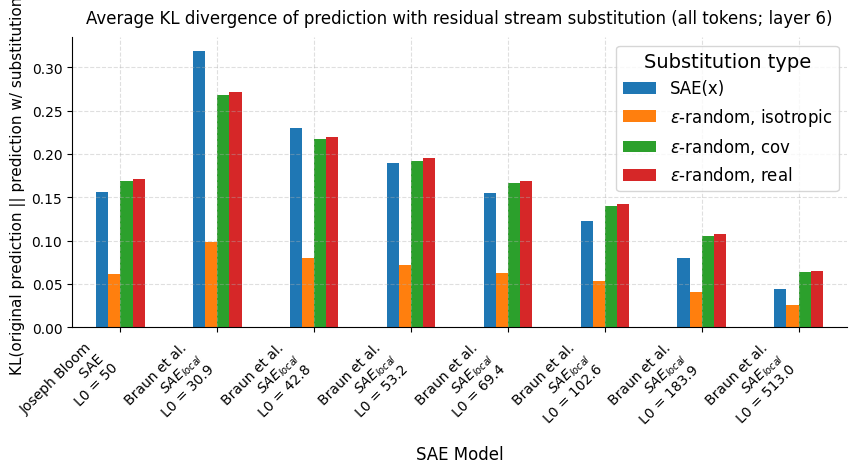

In [38]:
# kl_main_cols = ['substitution_kl', 'l2_error_preserving_substitution_kl', 'cos_corrected_substitution_kl']
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_main_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

plt.subplots_adjust(bottom=0.3)
plt.savefig(f"{cwd}/results/figures/pathological_error_analysis_SAE_local.svg")


In [32]:
df_interest = df_e2e[(df_e2e["L0"] > 40)]

pos = 'all'
# layers = list(range(12))
layers = [6]
sae_name = 'gpt2_resid_pre'

model_list = [f"e2e_{x}" for x in df_interest["id"]]

result_dfs = {}
for i in range(len(model_list)):
    data_path = os.path.join(
        cwd + '/error_eval_results',
        sae_name,
        f'{model_list[i]}_layer_6_pos_{pos}.csv',
    )
    result_dfs[i] = pd.read_csv(data_path)

model_names_list = [f"Braun et al. \n$SAE_{{e2e}}$ \nL0 = {x:.2f}" for x in df_interest["L0"]]


Text(0.5, 1.02, 'Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)')

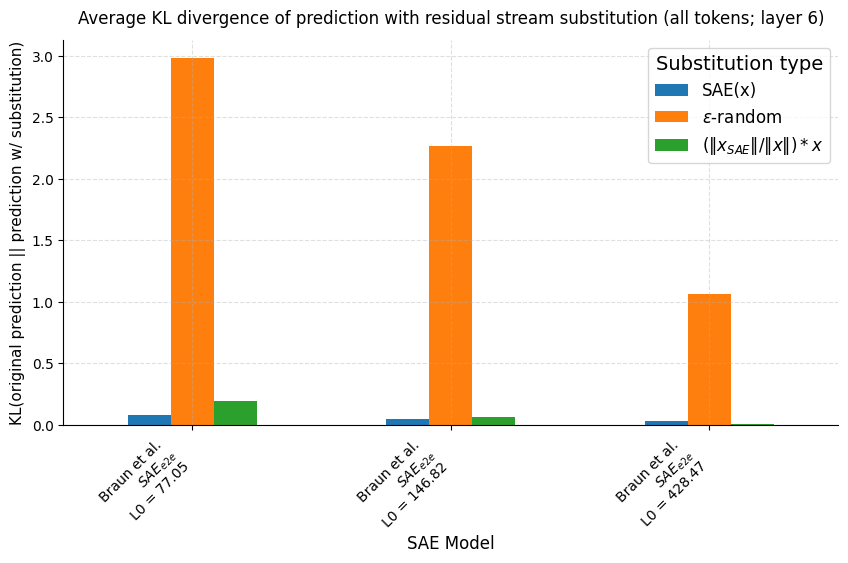

In [33]:
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_main_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

Text(0.5, 1.02, 'Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)')

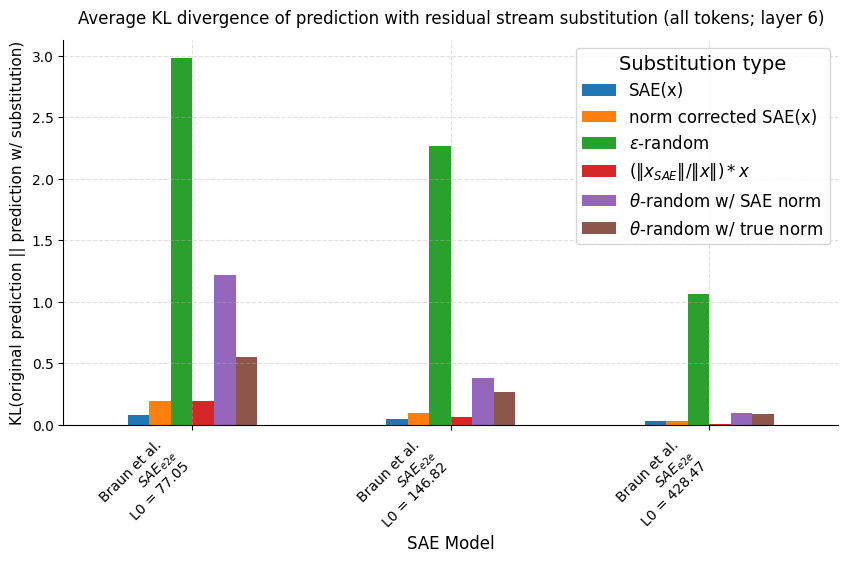

In [34]:
mean_df, fig, ax = plot_modelwise_kl_average(result_dfs, model_list, kl_all_cols, col_labels, model_names_list)
ax.set_title('Average KL divergence of prediction with residual stream substitution (all tokens; layer 6)', y=1.02)

In [54]:
df_interest = pd.concat([df_local, df_e2e, df_downstream])
df_interest = df_interest[(df_interest["L0"] > 35)].reset_index(drop = True)

In [127]:
pos = 'all'
# layers = list(range(12))
layers = [6]
sae_name = 'gpt2_resid_pre'

model_list = [f"e2e_{x}" for x in df_interest["id"]]

result_dfs = {}
for i in range(len(model_list)):
    data_path = os.path.join(
        cwd + '/error_eval_results',
        sae_name,
        f'{model_list[i]}_layer_6_pos_{pos}.csv',
    )
    result_dfs[i] = pd.read_csv(data_path)
    result_dfs[i]["norm_ratio"] = result_dfs[i]["sae_norm"]/result_dfs[0]["norm"]

model_names_list = [f"Braun et al. \n$SAE_{{e2e}}$ \nL0 = {x:.2f}" for x in df_interest["L0"]]


mean_df = pd.DataFrame({
        l: result_dfs[l].mean(axis=0) for l in range(len(model_names_list))
    }).T

mean_df["L0"] = df_interest["L0"]
mean_df["type"] = df_interest["run_type"]

In [158]:
# mean_df["L0"] = [f"{x:.2f}" for x in mean_df["L0"]]
mean_df["L0"] = mean_df["L0"].astype(float)

In [148]:
mean_df

,token,position,loss,substitution_loss,substitution_kl,norm_corrected_substitution_loss,norm_corrected_substitution_kl,cos_corrected_substitution_loss,cos_corrected_substitution_kl,l2_error_preserving_substitution_loss,...,mean_ablation_kl,sae_l0,sae_l1,reconstruction_error,norm,sae_norm,cos,norm_ratio,L0,type
0,4738.867746,63.0,3.557865,3.740642,0.229593,3.760289,0.248479,3.565278,0.007286,3.634387,...,5.283527,40.660933,138.028827,22.497630,102.278208,94.373838,0.960076,0.899714,42.80,local
1,4738.867746,63.0,3.557865,3.698316,0.189682,3.713387,0.204176,3.563941,0.005842,3.626248,...,5.283527,50.513713,145.083386,21.354410,102.278208,95.215543,0.964020,0.910483,53.22,local
2,4738.867746,63.0,3.557865,3.666962,0.154479,3.677946,0.165092,3.562532,0.004489,3.617041,...,5.283527,66.485167,154.668322,20.072467,102.278208,96.156254,0.968153,0.922236,69.43,local
3,4738.867746,63.0,3.557865,3.629418,0.122456,3.636425,0.129308,3.561583,0.003261,3.608255,...,5.283527,96.483264,169.283954,18.611699,102.278208,97.123783,0.972743,0.934783,102.58,local
4,4738.867746,63.0,3.557865,3.608510,0.079646,3.612754,0.083497,3.559753,0.002072,3.596668,...,5.283527,175.879770,197.522936,16.504589,102.278208,98.395249,0.978490,0.950195,183.95,local
5,4738.867746,63.0,3.557865,3.577006,0.043873,3.578736,0.045340,3.558596,0.001024,3.581848,...,5.283527,510.259476,277.317539,13.234724,102.278208,99.820891,0.986301,0.968101,512.99,local
6,4738.867746,63.0,3.557865,3.617729,0.122186,3.971430,0.442919,4.169816,0.666079,6.797677,...,5.283527,44.115774,64.343341,74.836169,102.278208,36.390879,0.835731,0.423581,39.68,e2e
7,4738.867746,63.0,3.557865,3.582738,0.075825,3.733876,0.195588,3.709804,0.193319,6.452552,...,5.283527,85.139187,112.566263,61.415820,102.278208,50.781455,0.900055,0.584175,77.05,e2e
8,4738.867746,63.0,3.557865,3.571621,0.048995,3.635303,0.094957,3.591098,0.065200,5.739427,...,5.283527,160.490219,183.393711,46.519907,102.278208,67.017225,0.936675,0.728556,146.82,e2e
9,4738.867746,63.0,3.557865,3.568404,0.027440,3.577641,0.032565,3.551617,0.007901,4.552629,...,5.283527,455.386434,380.288574,30.059134,102.278208,87.079444,0.965151,0.911352,428.47,e2e


In [63]:
mean_df_melt = pd.melt(mean_df, id_vars=['L0', 'type'], value_vars=kl_all_cols, value_name = "kl")

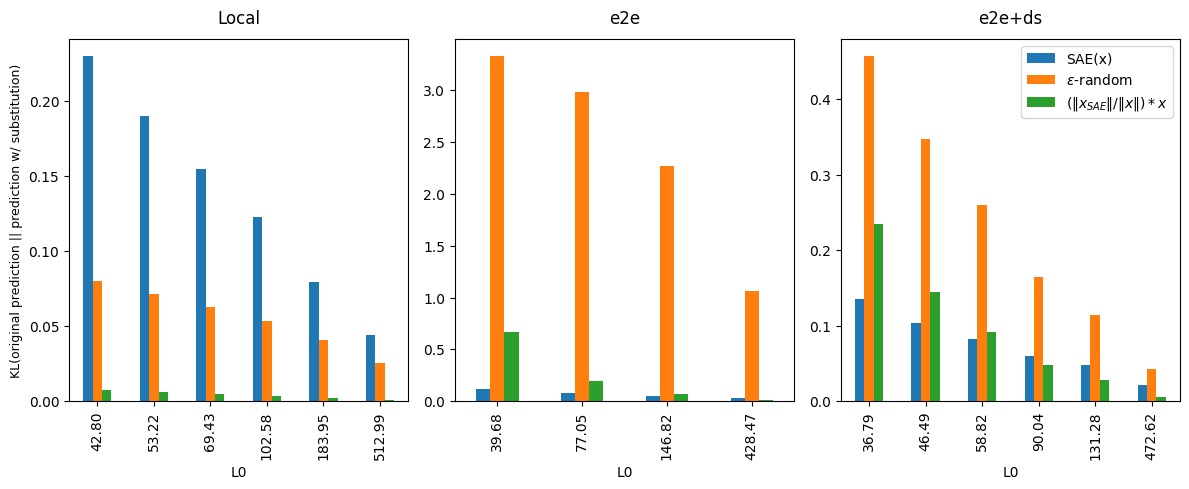

In [116]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = kl_main_cols

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(2):
    axes[i].get_legend().remove()

# for i in range(3):
#     axes[i].set_ylim([0, 3.5])

fig.tight_layout()

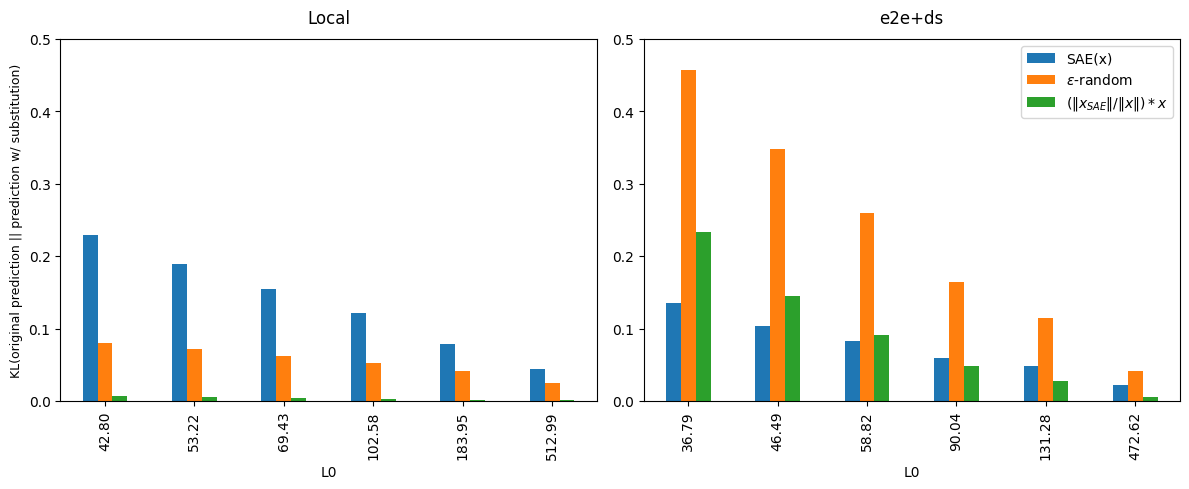

In [139]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
columns = kl_main_cols

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e+ds', y=1.02)

for i in range(1):
    axes[i].get_legend().remove()

for i in range(2):
    axes[i].set_ylim([0, 0.5])

fig.tight_layout()

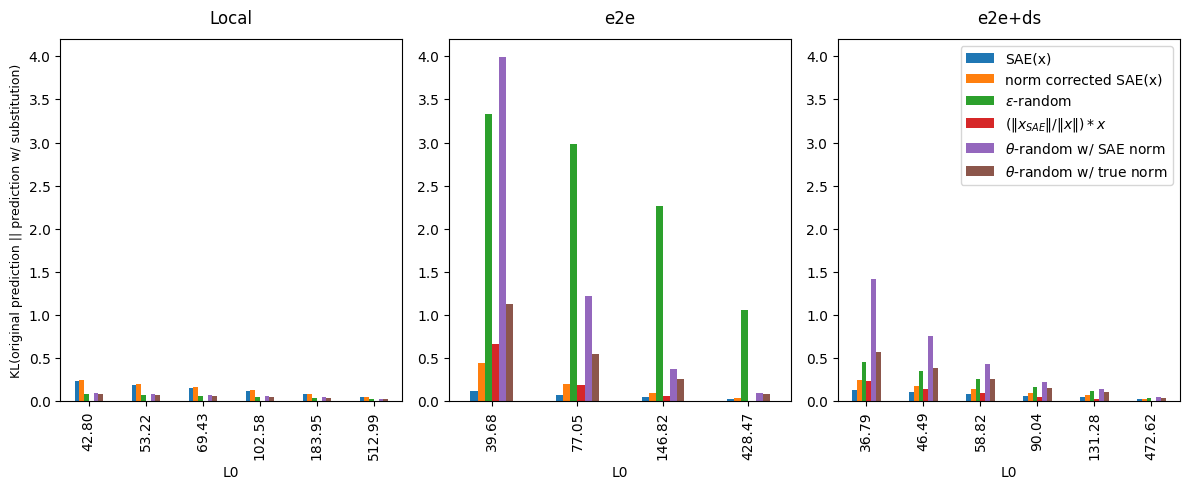

In [120]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = kl_all_cols

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(2):
    axes[i].get_legend().remove()

for i in range(3):
    axes[i].set_ylim([0, 4.2])

fig.tight_layout()

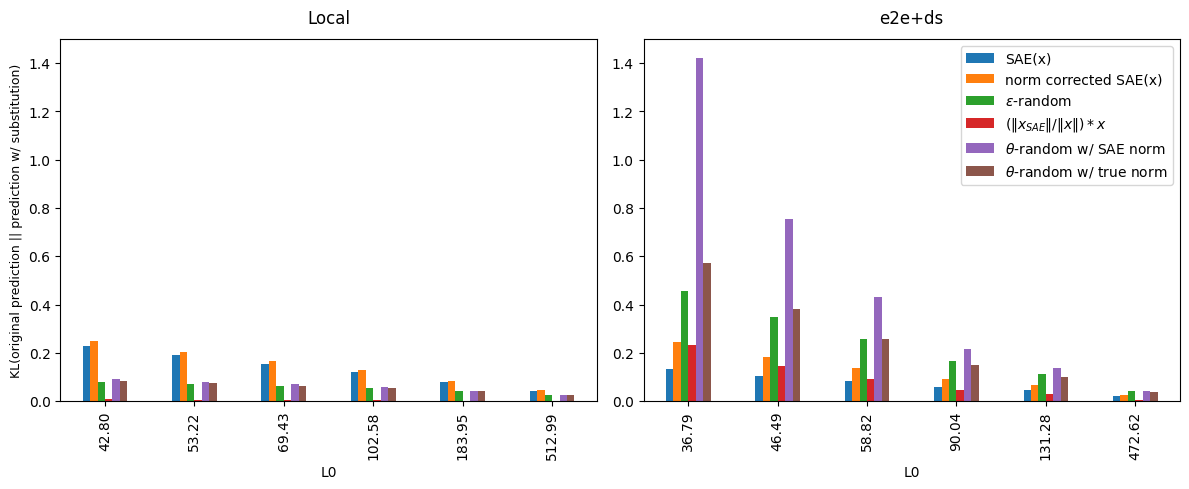

In [141]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
columns = kl_all_cols

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel('KL(original prediction || prediction w/ substitution)', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e+ds', y=1.02)

for i in range(1):
    axes[i].get_legend().remove()

for i in range(2):
    axes[i].set_ylim([0, 1.5])

fig.tight_layout()

In [128]:
mean_df.columns

Index(['token', 'position', 'loss', 'substitution_loss', 'substitution_kl',
       'norm_corrected_substitution_loss', 'norm_corrected_substitution_kl',
       'cos_corrected_substitution_loss', 'cos_corrected_substitution_kl',
       'l2_error_preserving_substitution_loss',
       'l2_error_preserving_substitution_kl',
       'cos_preserving_substitution_w_sae_norm_loss',
       'cos_preserving_substitution_w_sae_norm_kl',
       'cos_preserving_substitution_w_true_norm_loss',
       'cos_preserving_substitution_w_true_norm_kl', 'zero_ablation_loss',
       'zero_ablation_kl', 'mean_ablation_loss', 'mean_ablation_kl', 'sae_l0',
       'sae_l1', 'reconstruction_error', 'norm', 'sae_norm', 'cos',
       'norm_ratio', 'L0', 'type'],
      dtype='object')

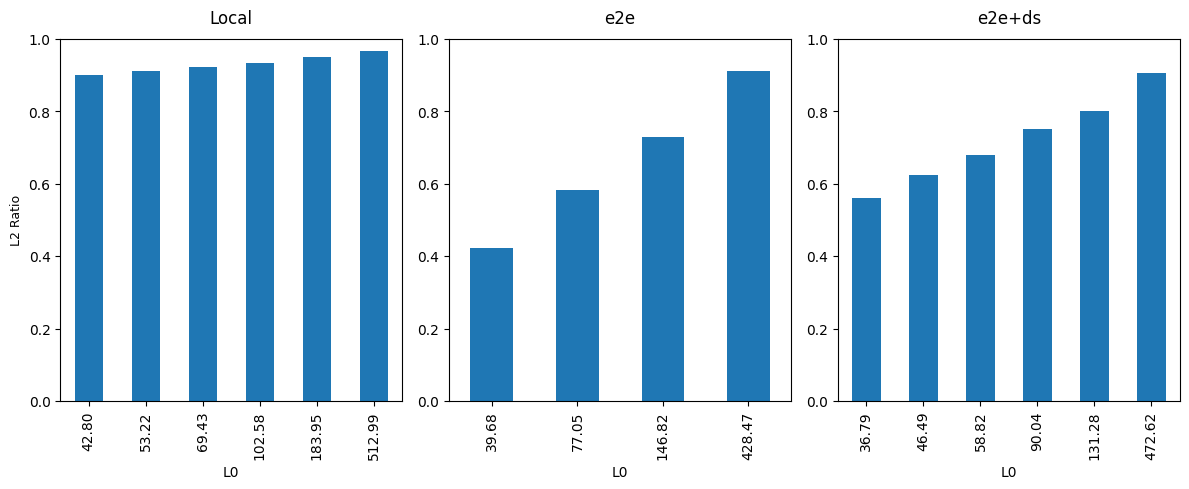

In [136]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = ["norm_ratio"]

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel('L2 Ratio', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(3):
    axes[i].get_legend().remove()
    axes[i].set_ylim([0, 1.0])

# for i in range(3):
#     axes[i].set_ylim([0, 3.5])

fig.tight_layout()

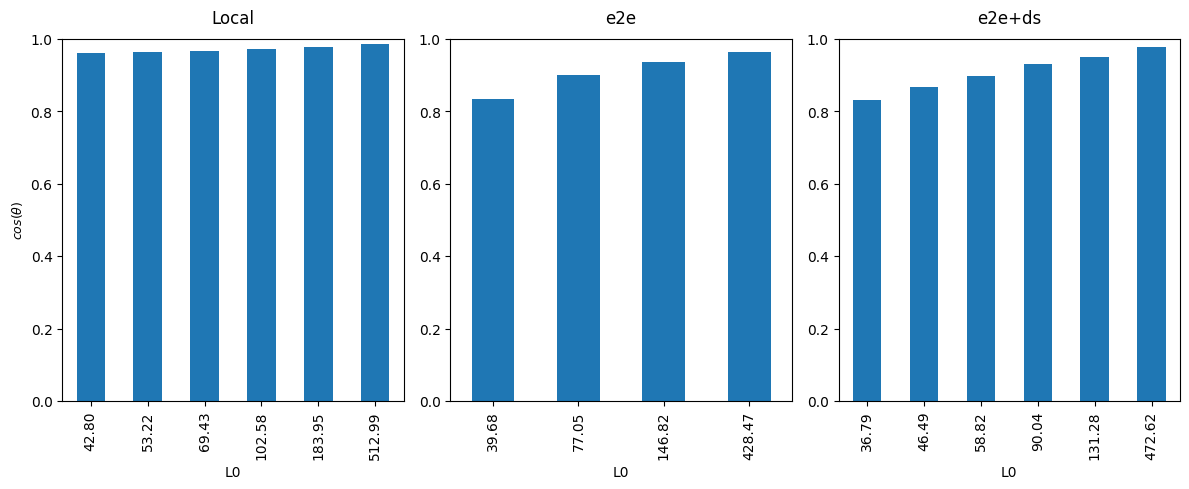

In [149]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = ["cos"]

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel(r'$cos(\theta)$', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(3):
    axes[i].get_legend().remove()
    axes[i].set_ylim([0, 1.0])

# for i in range(3):
#     axes[i].set_ylim([0, 3.5])

fig.tight_layout()

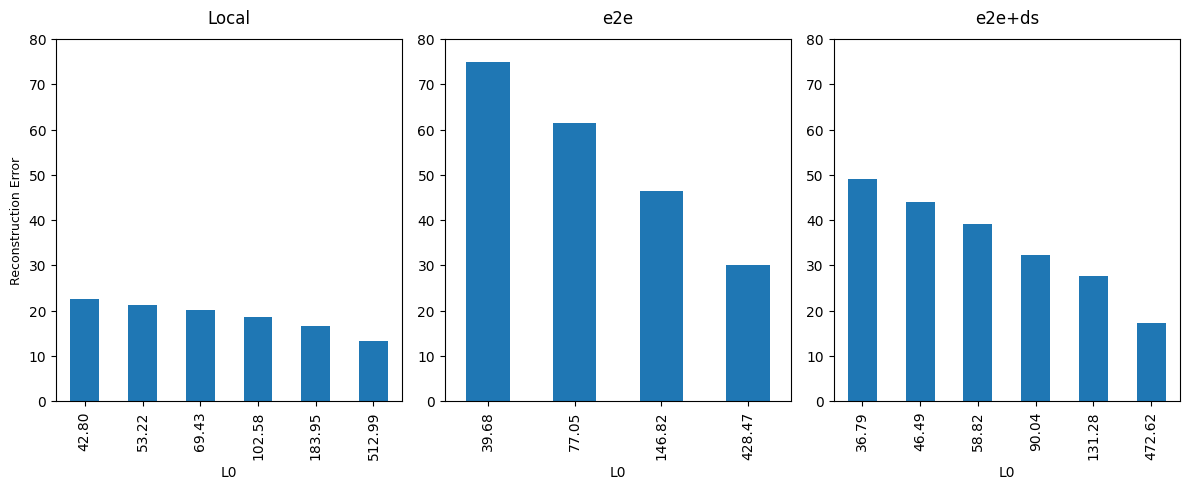

In [153]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = ["reconstruction_error"]

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[0])
axes[0].set_ylabel(r'Reconstruction Error', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", kind='bar', ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(3):
    axes[i].get_legend().remove()
    axes[i].set_ylim([0, 80])

# for i in range(3):
#     axes[i].set_ylim([0, 3.5])

fig.tight_layout()

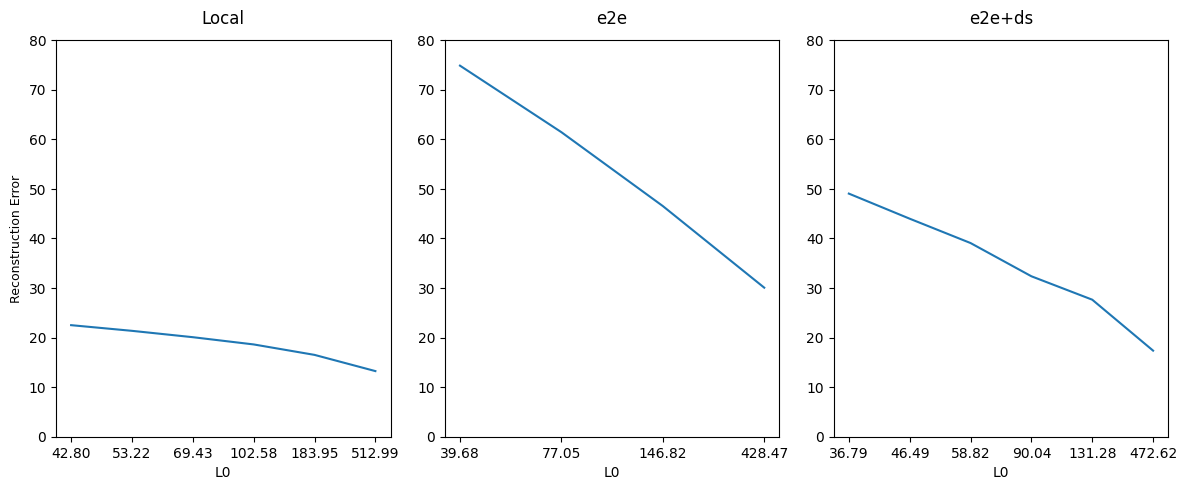

In [154]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(12, 5))
columns = ["reconstruction_error"]

mean_df_plot = mean_df[mean_df["type"] == "local"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", y = "reconstruction_error", ax=axes[0])
axes[0].set_ylabel(r'Reconstruction Error', fontsize=9)
axes[0].set_title('Local', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "e2e"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", y = "reconstruction_error", ax=axes[1])
axes[1].set_title('e2e', y=1.02)

mean_df_plot = mean_df[mean_df["type"] == "downstream"]
mean_df_plot[columns + ["L0"]].rename(columns=kl_col_labels).plot(x = "L0", y = "reconstruction_error", ax=axes[2])
axes[2].set_title('e2e+ds', y=1.02)

for i in range(3):
    axes[i].get_legend().remove()
    axes[i].set_ylim([0, 80])

# for i in range(3):
#     axes[i].set_ylim([0, 3.5])

fig.tight_layout()

<Axes: xlabel='reconstruction_error', ylabel='substitution_kl'>

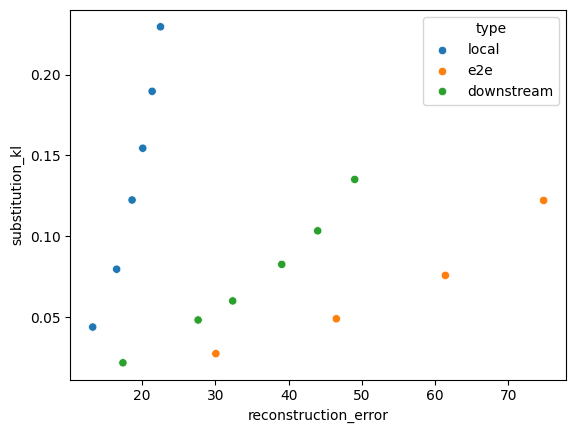

In [161]:
sns.scatterplot(data=mean_df, x="reconstruction_error", y="substitution_kl", hue="type")
